In [1]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PRIMARY_IMAGE_DIR = "../data/primary/images/US images"
PRIMARY_MASK_DIR  = "../data/primary/masks/Expert mask images"

KAGGLE_IMAGE_DIR = "../data/kaggle/images/US images"
KAGGLE_MASK_DIR  = "../data/kaggle/masks/Expert mask images"


In [3]:
primary_images = sorted(os.listdir(PRIMARY_IMAGE_DIR))
primary_masks  = sorted(os.listdir(PRIMARY_MASK_DIR))

print("Primary images:", len(primary_images))
print("Primary masks :", len(primary_masks))


Primary images: 1100
Primary masks : 1100


In [23]:
fname = random.choice(primary_images)
print("Selected file:", fname)


Selected file: 202202071313160025EM VASCULAR_slice_765.png


In [24]:
img_path  = os.path.join(PRIMARY_IMAGE_DIR, fname)
mask_path = os.path.join(PRIMARY_MASK_DIR, fname)

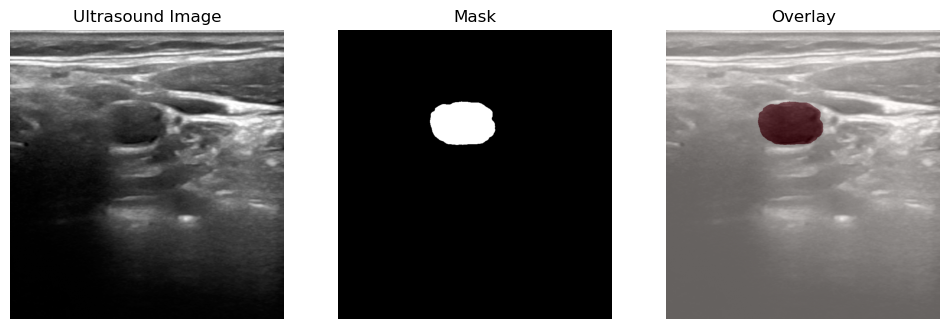

In [25]:
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Ultrasound Image")
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.4)
plt.axis("off")

plt.show()

In [7]:
import numpy as np

unique_values = np.unique(mask)
print("Unique values in mask:", unique_values)


Unique values in mask: [  0 255]


In [13]:
print("Image dtype:", image.dtype)
print("Min intensity:", np.min(image))
print("Max intensity:", np.max(image))
print("Mean intensity:", np.mean(image))

Image dtype: uint8
Min intensity: 0
Max intensity: 246
Mean intensity: 20.509437124440485


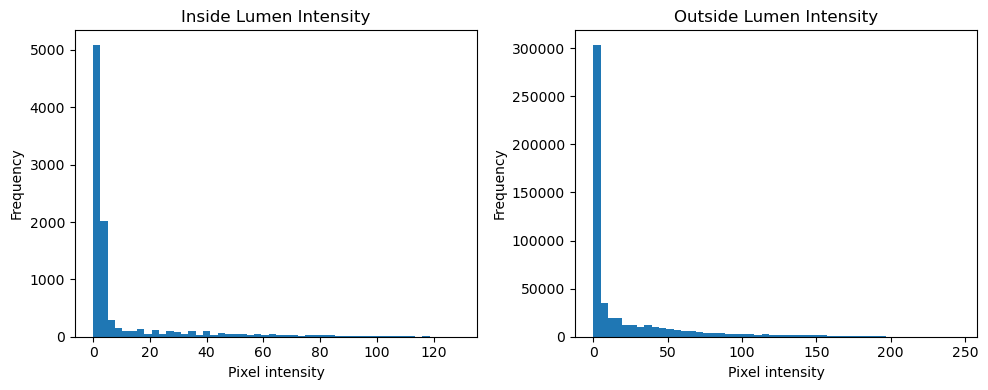

In [14]:

# Ensure mask is boolean
lumen_mask = mask == 255

# Pixels inside and outside lumen
inside_pixels = image[lumen_mask]
outside_pixels = image[~lumen_mask]

# Plot histograms
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(inside_pixels, bins=50)
plt.title("Inside Lumen Intensity")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(outside_pixels, bins=50)
plt.title("Outside Lumen Intensity")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
# Get list of image filenames
image_files = sorted(primary_images)

# Randomly pick 5 images
sample_files = random.sample(image_files, 5)

print("Image | Mean inside lumen | Mean outside lumen")
print("-" * 50)

for fname in sample_files:
    # Load image and mask
    image = cv2.imread(f"{PRIMARY_IMAGE_DIR}/{fname}", cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(f"{PRIMARY_MASK_DIR}/{fname}", cv2.IMREAD_GRAYSCALE)

    lumen_mask = mask == 255

    inside_mean = np.mean(image[lumen_mask])
    outside_mean = np.mean(image[~lumen_mask])

    print(f"{fname} | {inside_mean:.2f} | {outside_mean:.2f}")


Image | Mean inside lumen | Mean outside lumen
--------------------------------------------------
202201121850550042VAS_slice_1637.png | 11.63 | 18.11
202201121819140033VAS_slice_283.png | 11.57 | 17.20
202201121814260031VAS_slice_271.png | 13.38 | 23.89
202201121858500045VAS_slice_460.png | 14.14 | 23.36
202201121748100022VAS_slice_2918.png | 14.52 | 18.50


In [16]:
# --- parameters ---
BAND_WIDTH = 5  # pixels; small on purpose

# --- ensure boolean mask ---
lumen = (mask == 255)

# --- create boundary band ---
kernel = np.ones((3, 3), np.uint8)

dilated = cv2.dilate(lumen.astype(np.uint8), kernel, iterations=BAND_WIDTH)
eroded  = cv2.erode(lumen.astype(np.uint8), kernel, iterations=BAND_WIDTH)

boundary_band = (dilated.astype(bool)) & (~eroded.astype(bool))

# --- extract pixels ---
inside_pixels   = image[lumen]
boundary_pixels = image[boundary_band]

# --- stats ---
inside_mean = np.mean(inside_pixels)
inside_std  = np.std(inside_pixels)

boundary_mean = np.mean(boundary_pixels)
boundary_std  = np.std(boundary_pixels)

print("Inside lumen:")
print(f"  Mean = {inside_mean:.2f}, Std = {inside_std:.2f}")

print("\nBoundary band:")
print(f"  Mean = {boundary_mean:.2f}, Std = {boundary_std:.2f}")


Inside lumen:
  Mean = 14.52, Std = 25.12

Boundary band:
  Mean = 68.21, Std = 52.02


In [30]:
def extract_inner_biased_band(mask, inner_start=3, inner_end=10):
    """
    Extract an inner-biased lumen band to capture plaque-related texture.
    
    Parameters:
    mask (np.array): binary lumen mask (255 = lumen)
    inner_start (int): erosion from boundary (start of band)
    inner_end (int): deeper erosion (end of band, > inner_start)
    
    Returns:
    np.array: boolean mask of inner-biased band
    """
    lumen = (mask == 255).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)

    erode_outer = cv2.erode(lumen, kernel, iterations=inner_start)
    erode_inner = cv2.erode(lumen, kernel, iterations=inner_end)

    inner_band = (erode_outer == 1) & (erode_inner == 0)
    return inner_band


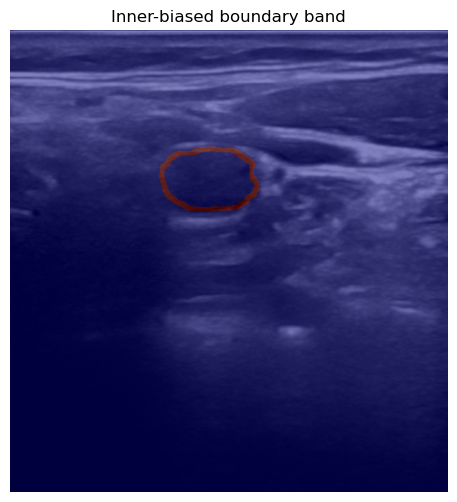

In [31]:
inner_band = extract_inner_biased_band(mask, inner_start=3, inner_end=10)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.imshow(inner_band, cmap='jet', alpha=0.5)
plt.title("Inner-biased boundary band")
plt.axis("off")
plt.show()
